# Artefact Reduction by Homogeneous Field Correction

This section explains how Homogeneous Field Correction (HFC) is used to attenuate artefacts in the OPM  data. Homogeneous Field Correction (HFC) is a preprocessing technique that suppresses artefacts that manifest as spatially uniform magnetic fields across the sensor array [1]. These artefacts are generated by sources in the environment that may come from electrical devices or moving magnetic objects. Examples are ventilation systems, belt buckles on the participant, elevators, driving cars, magnetic door latches, as well as vibrations. Another large contribution comes from movements in which the sensor array is moving within the recidual fields of the magnetically shielded room. These artefacts tend to generate magnetic fields that are fairly spatially homogenous as they are typically far away from the sensor array. Brain activity, on the other hand, produces magnetic fields which are less homogenous with higher spatial gradients as the fields are generated by neuronal sources with proximity to the sensors. 
The goal of HFC is to remove the component of the measured signal that is common across all sensors, assuming it arises from a spatially uniform (homogeneous) field. By applying HFC, the quality of the OPM data is improved, background noise is reduced, and the OPM system becomes more accurate in detecting and localizing the true magnetic sources from the brain activity.This section explains how HFC can be applied in MNE Python to attenuate artefacts in the OPM data. 

HFC operates by applying a linear projection applied to all the sensors. If there are sensors that are 'flat' or reflect excessive noise, they must be removed prior to the HFC procedure such that they do not contribute to spreading noise. Therefore, prior to applying HFC, it is important to identify and exclude 'bad' sensors. 

### Import the necessary modules
Below are the required Python modules to be imported for this section

In [1]:
import mne
import os
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import array
from pprint import pprint
import json
import os.path as op
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
    write_meg_calibration,
    write_meg_crosstalk,
    write_raw_bids,
)
from mne_bids.stats import count_events

## File overview

The chapter relies on the file (embedded in BIDS):
```
< BIDS_ROOT >/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif
```
and generates the output file in the 'derivatives' folder of the BIDS 
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
```

In [2]:
subject = '01'  
session = '01'  
task = 'SpAtt'
run = '01'  
meg_suffix = 'meg'
meg_extension = '.fif'
events_suffix = 'events'
events_extension = '.tsv'

data_path = 'E:/new_fieldline/sub-H'


bids_root = op.join(data_path, "Fieldline_Spatt_BIDS")
bids_path = BIDSPath(subject=subject, session=session,
                     task=task, run=run, suffix=meg_suffix, 
                     extension=meg_extension, root=bids_root)

Create a 'derivative folder' where the processed data will be stored:

In [3]:
deriv_root = op.join(bids_root, 'derivatives/preprocessing')  # output path

deriv_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run, suffix=meg_suffix, root=deriv_root).mkdir()

deriv_fname = bids_path.basename.replace('meg', 'raw_hfc') # output filename
deriv_file_1 = op.join(deriv_path.directory, deriv_fname)

Read the Raw Data

In [4]:
raw = read_raw_bids(bids_path=bids_path, verbose=False,extra_params={'preload':True})

## Idenfity the faulty sensors

The first step is to flag sensors as “bad” based on what we observed during acquisition. After that bad‐sensor list is further augmented by identifying outliers based on the power spectral density estimates. We did not see any such bad sensors during the data acquisition however we few sensors were failed to initialize hence they were not included in the recording.

Now, additional noisy bad sensors will be identified based on the average power spectral density (PSD) of each sensor. Sensors with an average PSD value crossing a predefined threshold will be flagged as bad and hence  not contribute towards the HFC filtering. 

## Calculate and plot the PSDs

In [5]:
n_fft = 2000
raw_PSD = raw.compute_psd(method="welch", fmin=0.1, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft/2))
psds = raw_PSD.get_data() # units are in T^2/Hz
freqs = raw_PSD.freqs 
psd_db = 10 * np.log10(psds * 1e30)# Ref power: 1fT^2=1e-30T^2
average_power = np.mean(psd_db, axis=1)

Effective window size : 2.000 (s)


#### To plot the result using the commands 

Plotting power spectral density (dB=True).


C:\Users\arakshit\mne-python\1.10.1_0\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


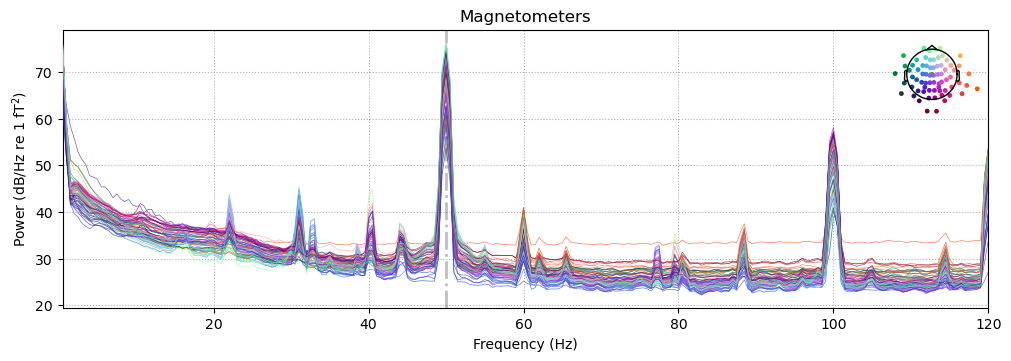

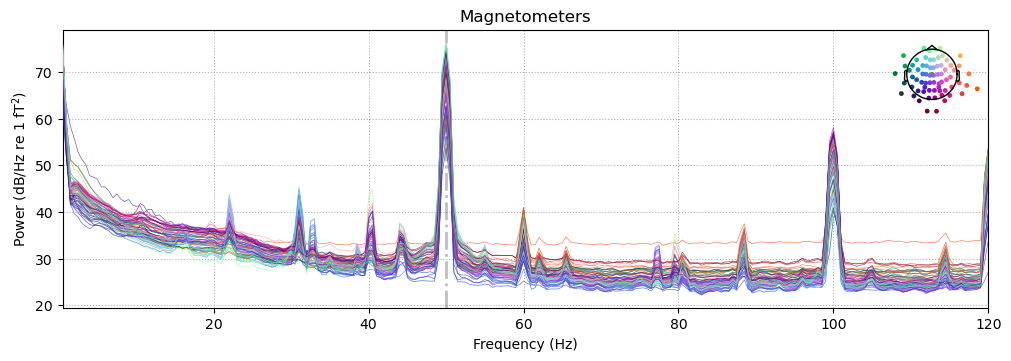

In [6]:
raw_PSD.plot() ## This is the default command of MNE to plot PSD

As can be overserved, there are several peaks in the spectra speaking to contamination from external sources. There are also several 'noisy' sensors with high broadband power.

### Histograms of sensor power

As a next step, histograms of the power averaged across freqeuncues will be plotted for the different sensors.

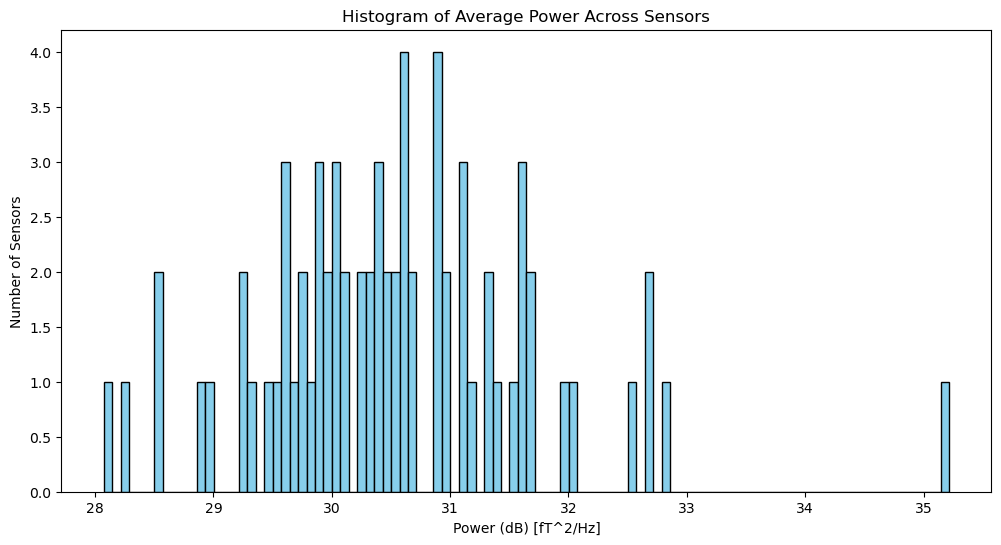

In [7]:
%matplotlib inline
plt.figure(figsize=(12, 6))
BNS = 100
plt.hist(average_power, bins=BNS,color='skyblue',edgecolor='black'); plt.xlabel('Power (dB) [fT^2/Hz]');plt.ylabel('Number of Sensors'); plt.title('Histogram of Average Power Across Sensors');

We will here reject sensors with a noise level above 35 db. This is admittedly a bit arbitrary but the point is to provide an example of automatic thresholding. 

### Identifying and flagging sensors with high power

To identify the sensors above the threshold of 35 dB write

In [8]:
sensor_names = raw_PSD.ch_names
sensors_above_threshold = [sensor_names[i] for i, avg in enumerate(average_power) if avg > 33]
print(sensors_above_threshold)

['R508_bz-s27']


#### Flag the sensors above the threshold as bad with the data structure. This will be done by augmenting the existing list of bad sensors

In [9]:
raw.info['bads']=sensors_above_threshold
print(raw.info['bads'])

['R508_bz-s27']


**Question 1:** Where are the noisy sensors located? Identify and mark the sensor on the layout below:

**Question 2:** Plot the time course of a few noisy sensors and compare to non-noisy sensors. What characterizes the noisy sensors?

## Applying Homogenous Field Correction

Before doing HFC plot the PSD excluding the bad sensors. 

#### Plot of the raw data before pre-processing

For brevity, we will plot data from a subset of sensors, selecting every 5th sensor.

Text(0.5, 1.0, 'Before Applying HFC')

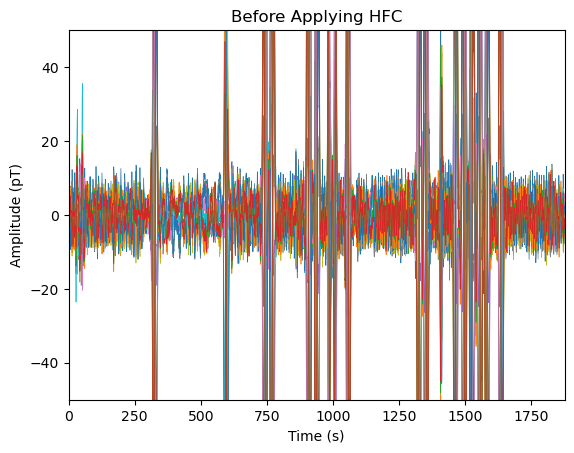

In [10]:
picks = mne.pick_types(raw.info, meg=True,exclude='bads')

amp_scale = 1e12  # Converting to pico Tesla(pT)
stop = len(raw.times)-300
step = 500
data_ds, time_ds = raw[picks[::5], :stop]
data_ds, time_ds = data_ds[:, ::step]* amp_scale , time_ds[::step]

plt.plot(time_ds, data_ds.T - np.mean(data_ds, axis=1),lw=0.5);
plt.ylim(-50, 50)
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude (pT)')
plt.xlim(time_ds[0], time_ds[-1])
#plt.grid(True)
plt.title("Before Applying HFC")


### Interference rejection using Homogeneous Field Correction

In [12]:
rawHFC=raw.copy()
bad = rawHFC.info['bads'] + ['s66_bz']
picks = mne.pick_types(rawHFC.info, meg=True, exclude=bad)
projs = mne.preprocessing.compute_proj_hfc(rawHFC.info, order=2,picks=picks)
rawHFC.add_proj(projs).apply_proj(verbose="error")

8 projection items deactivated


<Raw | sub-01_ses-01_task-SpAtt_run-01_meg.fif, 72 x 1876100 (1876.1 s), ~1.01 GiB, data loaded>

Plotting the raw data after applying HFC

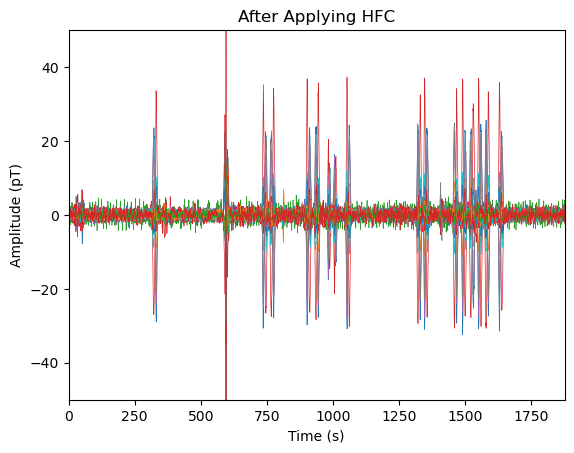

In [13]:
picks = mne.pick_types(rawHFC.info, meg=True,exclude='bads')

amp_scale = 1e12  # Converting to pico Tesla(pT)
stop = len(raw.times) - 300
step = 500
data_ds, time_ds = rawHFC[picks[::5], :stop]
data_ds, time_ds = data_ds[:, ::step]* amp_scale , time_ds[::step]

plt.plot(time_ds, data_ds.T - np.mean(data_ds, axis=1),lw=0.5);
plt.ylim(-50, 50);
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude (pT)')
plt.xlim(time_ds[0], time_ds[-1])
#plt.grid(True)
plt.title("After Applying HFC")
plt.show()

The artifacts are now clearly reduced showing the utility of the HFC. These artifacts prior to the HFC were likely due to the participant moving within room. Despite the shielding, there will be recidual field remaining that procudes a signal when the sensors are moving within the recidual field. 

### Powerspectra after HFC

Another way to inspect the effects of HFC is to consider the power-spectra

In [14]:
n_fft = 2000
raw_PSD = raw.compute_psd(method="welch", fmin=0.1, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft/2))
psds = raw_PSD.get_data() # units are in T^2/Hz
freqs = raw_PSD.freqs 
psd_db = 10 * np.log10(psds * 1e30)# Ref power: 1fT^2=1e-30T^2

raw_PSDc = rawHFC.compute_psd(method="welch", fmin=0.1, fmax=120, picks='mag', n_fft=n_fft, n_overlap=int(n_fft/2))
psdsc = raw_PSDc.get_data() # units are in T^2/Hz
freqsc = raw_PSDc.freqs 
psd_dbc = 10 * np.log10(psdsc * 1e30)  # Ref power: 1fT^2=1e-30T^2   

Effective window size : 2.000 (s)
Effective window size : 2.000 (s)


For comparison, plot the spectra next to each other for no HFC and for HFC: 

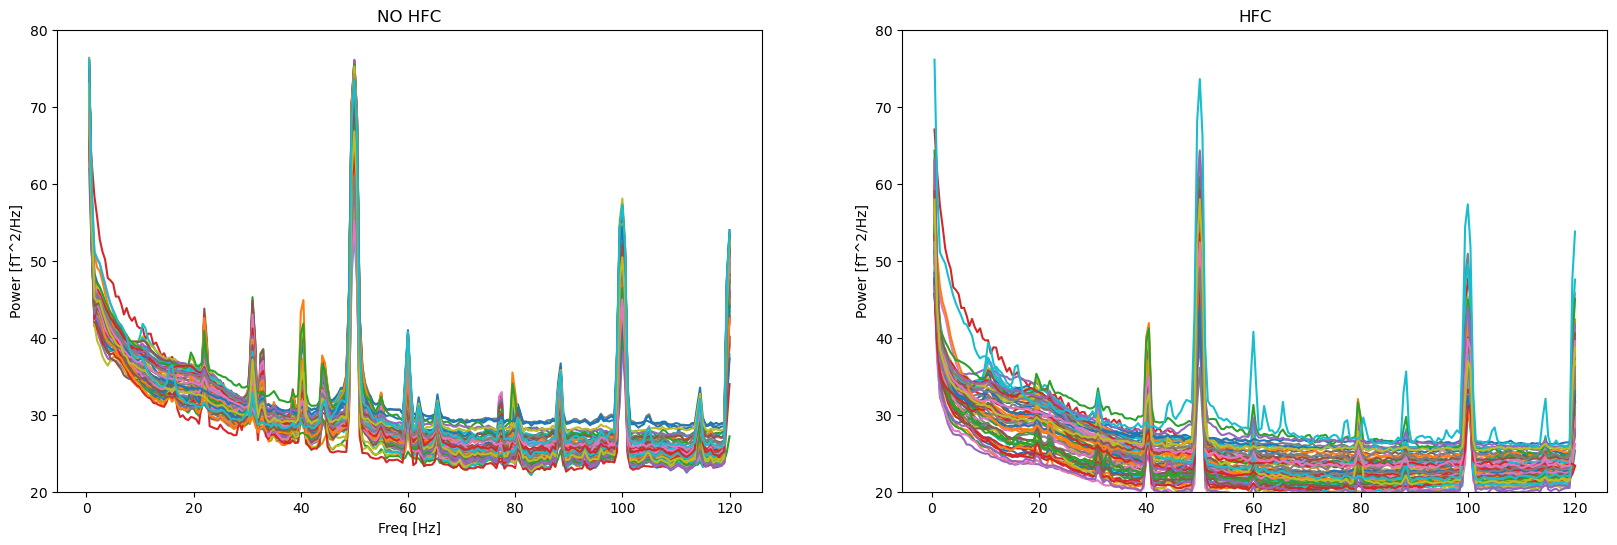

In [15]:
plt.figure(figsize=(20, 6))

plt.subplot(1,2,1)
plt.plot(freqs,psd_db.T);plt.ylim(20, 80);plt.xlabel('Freq [Hz]');plt.ylabel('Power [fT^2/Hz]');plt.title('NO HFC');

plt.subplot(1,2,2)
plt.plot(freqsc,psd_dbc.T);plt.ylim(20, 80);plt.xlabel('Freq [Hz]');plt.ylabel('Power [fT^2/Hz]');plt.title('HFC');

The power over a wide frequency range is reduced following HFC. This becomes more evident when considering the spectra averaged over sensors

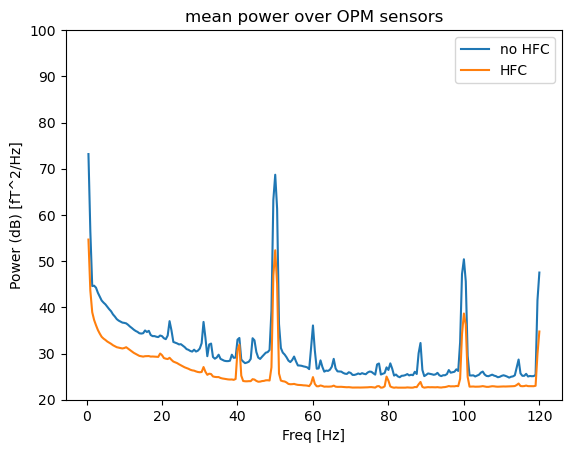

In [16]:
plt.plot(freqs,np.mean(psd_db.T,axis=1),label='no HFC')
plt.plot(freqsc,np.mean(psd_dbc.T,axis=1), label='HFC')
plt.legend();plt.ylim(20, 100);plt.xlabel('Freq [Hz]');plt.ylabel('Power (dB) [fT^2/Hz]');plt.title('mean power over OPM sensors');

The reduction in power after HFC is now evident, particularly for the slower frequencies. The reduction is explained by artefacts being attenuated; most likely artefacts are due to head movements. Several of the spectral peaks are also reduces. However the 40 Hz peak remain. This effect might system specific at the site. 

#### Store the filtered data within the derivatives folder of the BIDS directory.

In [17]:
rawHFC.save(deriv_file_1, overwrite=True) 

Writing E:\new_fieldline\sub-H\Fieldline_Spatt_BIDS\derivatives\preprocessing\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_raw_hfc.fif


C:\Users\arakshit\AppData\Local\Temp\ipykernel_45632\651356149.py:1: RuntimeWarning: This filename (E:\new_fieldline\sub-H\Fieldline_Spatt_BIDS\derivatives\preprocessing\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_raw_hfc.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  rawHFC.save(deriv_file_1, overwrite=True)


Closing E:\new_fieldline\sub-H\Fieldline_Spatt_BIDS\derivatives\preprocessing\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_raw_hfc.fif
[done]


[WindowsPath('E:/new_fieldline/sub-H/Fieldline_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_raw_hfc.fif')]

## Preregistration and Publication

The raw data is subjected to homogeneous field correction (HFC) which is the most important step of the pre-processing stage. The HFC assumes the external interference as a homogeneous field and attempts to separate the signal from the interference. We recommend using the homogeneous field correction which is able to work on low order data. HFC targets interference from distant magnetic sources. Such sources produce nearly uniform magnetic fields across all sensors, unlike brain signals, which vary with sensor position. HFC works by estimating this homogeneous field by finding the best-fit constant field vector across the sensor array at each time point and subtracting it from each sensor’s data. This removes spatially constant noise while preserving the local field variations generated by the brain sources.

## References

[1] Tierney, T.M., Alexander, N., Mellor, S., Holmes, N., Seymour, R., O'Neill, G.C., Maguire, E.A., & Barnes, G.R. (2021) *Modelling optically pumped magnetometer interference in MEG as a spatially homogeneous magnetic field.* Neuroimage. 244:118484. https://doi.org/10.1016/j.neuroimage.2021.118484. 
